# 🚀 DeepMost Agentic SDR — Exploratory Data Analysis

**Comprehensive EDA for the AI-driven Sales Development Representative System**

This notebook covers:
- 📁 Data Loading & Quality Assessment
- 📈 Business Metrics & KPIs Dashboard
- 🎯 Outcome & Score Distribution Analysis
- 💬 Conversation Dynamics & NLP Insights
- 🧱 Objection Analysis
- 🔗 Correlation & Feature Analysis
- 📊 Statistical Hypothesis Testing
- 🔬 Cluster Analysis
- 📉 Time-Series Trends

---

## 0. ⚙️ Setup & Imports

In [1]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json
import os
import warnings
from pathlib import Path
from datetime import datetime
from collections import Counter
import re

# ML / Stats imports
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu

warnings.filterwarnings('ignore')

# Matplotlib style
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    try:
        plt.style.use('seaborn-whitegrid')
    except:
        plt.style.use('ggplot')

sns.set_palette('husl')

# Paths
DATA_DIR = Path('../data/processed')
CONVERSATIONS_DIR = Path('../data/raw/conversations')

print('✅ Imports loaded successfully')

✅ Imports loaded successfully


## 1. 📁 Data Loading & Quality Assessment

In [2]:
# Load all datasets
try:
    master_df = pd.read_csv(DATA_DIR / 'simulations_master.csv')
    turns_df  = pd.read_csv(DATA_DIR / 'conversation_turns.csv')
    metrics_df = pd.read_csv(DATA_DIR / 'simulation_metrics.csv')

    print('📊 Data Loaded Successfully!')
    print(f'   • Master Records  : {len(master_df):,}')
    print(f'   • Conversation Turns: {len(turns_df):,}')
    print(f'   • Metrics Records : {len(metrics_df):,}')
    print(f'   • Unique Conversations: {metrics_df["simulation_id"].nunique():,}')
    DATA_LOADED = True
except FileNotFoundError as e:
    print('⚠️  Data files not found. Run simulations first!')
    print(f'   Error: {e}')
    DATA_LOADED = False
    metrics_df = pd.DataFrame()
    turns_df   = pd.DataFrame()
    master_df  = pd.DataFrame()

📊 Data Loaded Successfully!
   • Master Records  : 773
   • Conversation Turns: 6,466
   • Metrics Records : 769
   • Unique Conversations: 769


In [3]:
def data_quality_report(df, name):
    """Print a data quality summary for a DataFrame."""
    if df.empty:
        print(f'⚠️  {name} is empty.')
        return

    print(f"\n{'='*50}")
    print(f'📋 Data Quality Report: {name}')
    print(f"{'='*50}")
    print(f'Total Records : {len(df):,}')

    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    if missing.sum() > 0:
        print('\n⚠️  Missing Values:')
        for col in missing[missing > 0].index:
            print(f'   • {col}: {missing[col]} ({missing_pct[col]}%)')
    else:
        print('\n✅  No missing values!')

    dupes = df.duplicated().sum()
    print(f'Duplicate rows: {dupes}')
    return df.describe(include='all')

if DATA_LOADED:
    data_quality_report(metrics_df, 'Simulation Metrics')
    data_quality_report(turns_df,   'Conversation Turns')


📋 Data Quality Report: Simulation Metrics
Total Records : 769

⚠️  Missing Values:
   • objection_type: 6 (0.78%)
Duplicate rows: 0

📋 Data Quality Report: Conversation Turns
Total Records : 6,466

⚠️  Missing Values:
   • message: 8 (0.12%)
Duplicate rows: 0


## 2. 📈 Business Metrics & KPIs

In [4]:
if DATA_LOADED:
    kpis = {
        'Total Simulations'      : len(metrics_df),
        'Success Rate'           : f"{metrics_df['outcome_binary'].mean()*100:.1f}%",
        'Average Score'          : f"{metrics_df['score'].mean():.2f}/10",
        'Median Score'           : metrics_df['score'].median(),
        'Avg Conversation Length': f"{metrics_df['total_conversation_length'].mean():.0f} words",
        'Avg Turns per Call'     : f"{metrics_df['num_turns'].mean():.1f}",
        'Seller Talk Ratio'      : f"{metrics_df['word_ratio_seller_buyer'].mean():.2f}",
    }
    print('🎯 KEY PERFORMANCE INDICATORS')
    print('='*40)
    for k, v in kpis.items():
        print(f'{k}: {v}')
else:
    print('⚠️  No data available.')

🎯 KEY PERFORMANCE INDICATORS
Total Simulations: 769
Success Rate: 16.8%
Average Score: 4.30/10
Median Score: 4.0
Avg Conversation Length: 429 words
Avg Turns per Call: 4.2
Seller Talk Ratio: 1.26


In [5]:
# Interactive KPI Dashboard (Plotly)
if DATA_LOADED:
    outcome_counts = metrics_df['outcome_label'].value_counts()

    fig = make_subplots(
        rows=2, cols=3,
        subplot_titles=('Win Rate %', 'Avg Score', 'Total Simulations',
                        'Outcome Distribution', 'Score Distribution', 'Seller Talk Ratio'),
        specs=[
            [{'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}],
            [{'type': 'pie'},       {'type': 'histogram'}, {'type': 'histogram'}],
        ]
    )

    fig.add_trace(go.Indicator(
        mode='gauge+number+delta',
        value=metrics_df['outcome_binary'].mean() * 100,
        delta={'reference': 50},
        gauge={'axis': {'range': [0, 100]}, 'bar': {'color': 'red'}},
        title={'text': 'Win Rate %'}
    ), row=1, col=1)

    fig.add_trace(go.Indicator(
        mode='number+delta',
        value=metrics_df['score'].mean(),
        delta={'reference': 5},
        title={'text': 'Avg Score'}
    ), row=1, col=2)

    fig.add_trace(go.Indicator(
        mode='number',
        value=len(metrics_df),
        title={'text': 'Total Simulations'}
    ), row=1, col=3)

    fig.add_trace(go.Pie(
        labels=outcome_counts.index.tolist(),
        values=outcome_counts.tolist(),
        marker={'colors': ['#2ecc71', '#e74c3c', '#f39c12']}
    ), row=2, col=1)

    fig.add_trace(go.Histogram(
        x=metrics_df['score'],
        nbinsx=10,
        marker_color='#3498db',
        name='Score'
    ), row=2, col=2)

    fig.add_trace(go.Histogram(
        x=metrics_df['word_ratio_seller_buyer'],
        nbinsx=20,
        marker_color='#9b59b6',
        name='Talk Ratio'
    ), row=2, col=3)

    fig.update_layout(height=700, title_text='📊 Business Metrics Dashboard', showlegend=False)
    fig.show()

## 3. 🎯 Outcome & Score Distribution

Outcome Distribution:
outcome_label
Failure    604
Success    129
Pending     35
Error        1
Name: count, dtype: int64

Success Rate: 16.8%


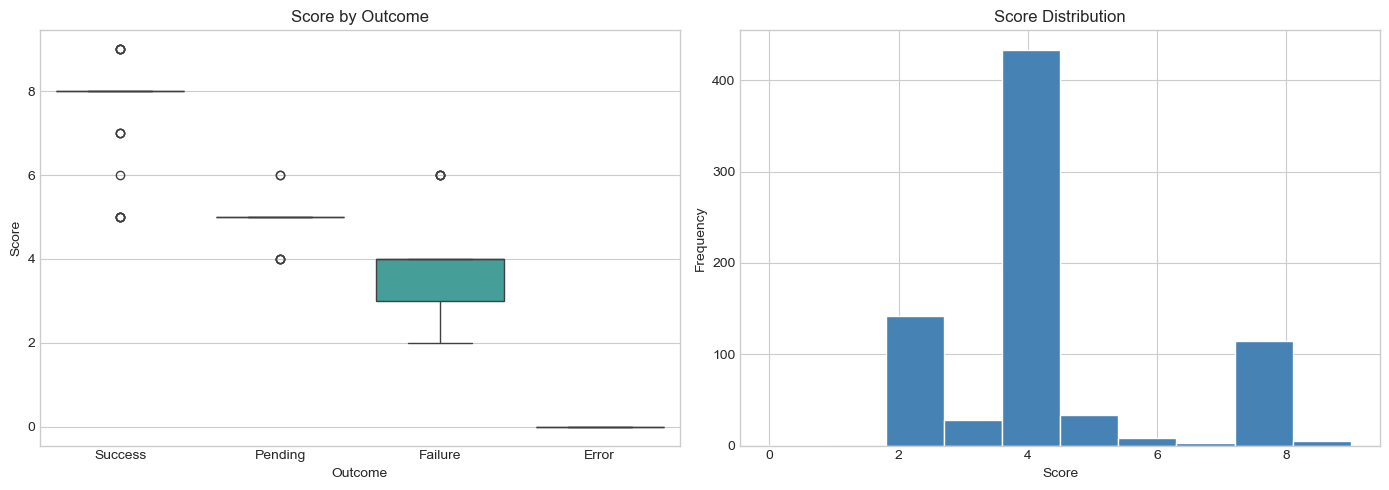

In [6]:
if DATA_LOADED:
    print('Outcome Distribution:')
    print(metrics_df['outcome_label'].value_counts())
    print(f"\nSuccess Rate: {metrics_df['outcome_binary'].mean()*100:.1f}%")

    # Score by outcome box plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.boxplot(data=metrics_df, x='outcome_label', y='score', ax=axes[0], palette='husl')
    axes[0].set_title('Score by Outcome')
    axes[0].set_xlabel('Outcome')
    axes[0].set_ylabel('Score')

    metrics_df['score'].hist(bins=10, ax=axes[1], color='steelblue', edgecolor='white')
    axes[1].set_title('Score Distribution')
    axes[1].set_xlabel('Score')
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

## 4. 💬 Conversation Dynamics

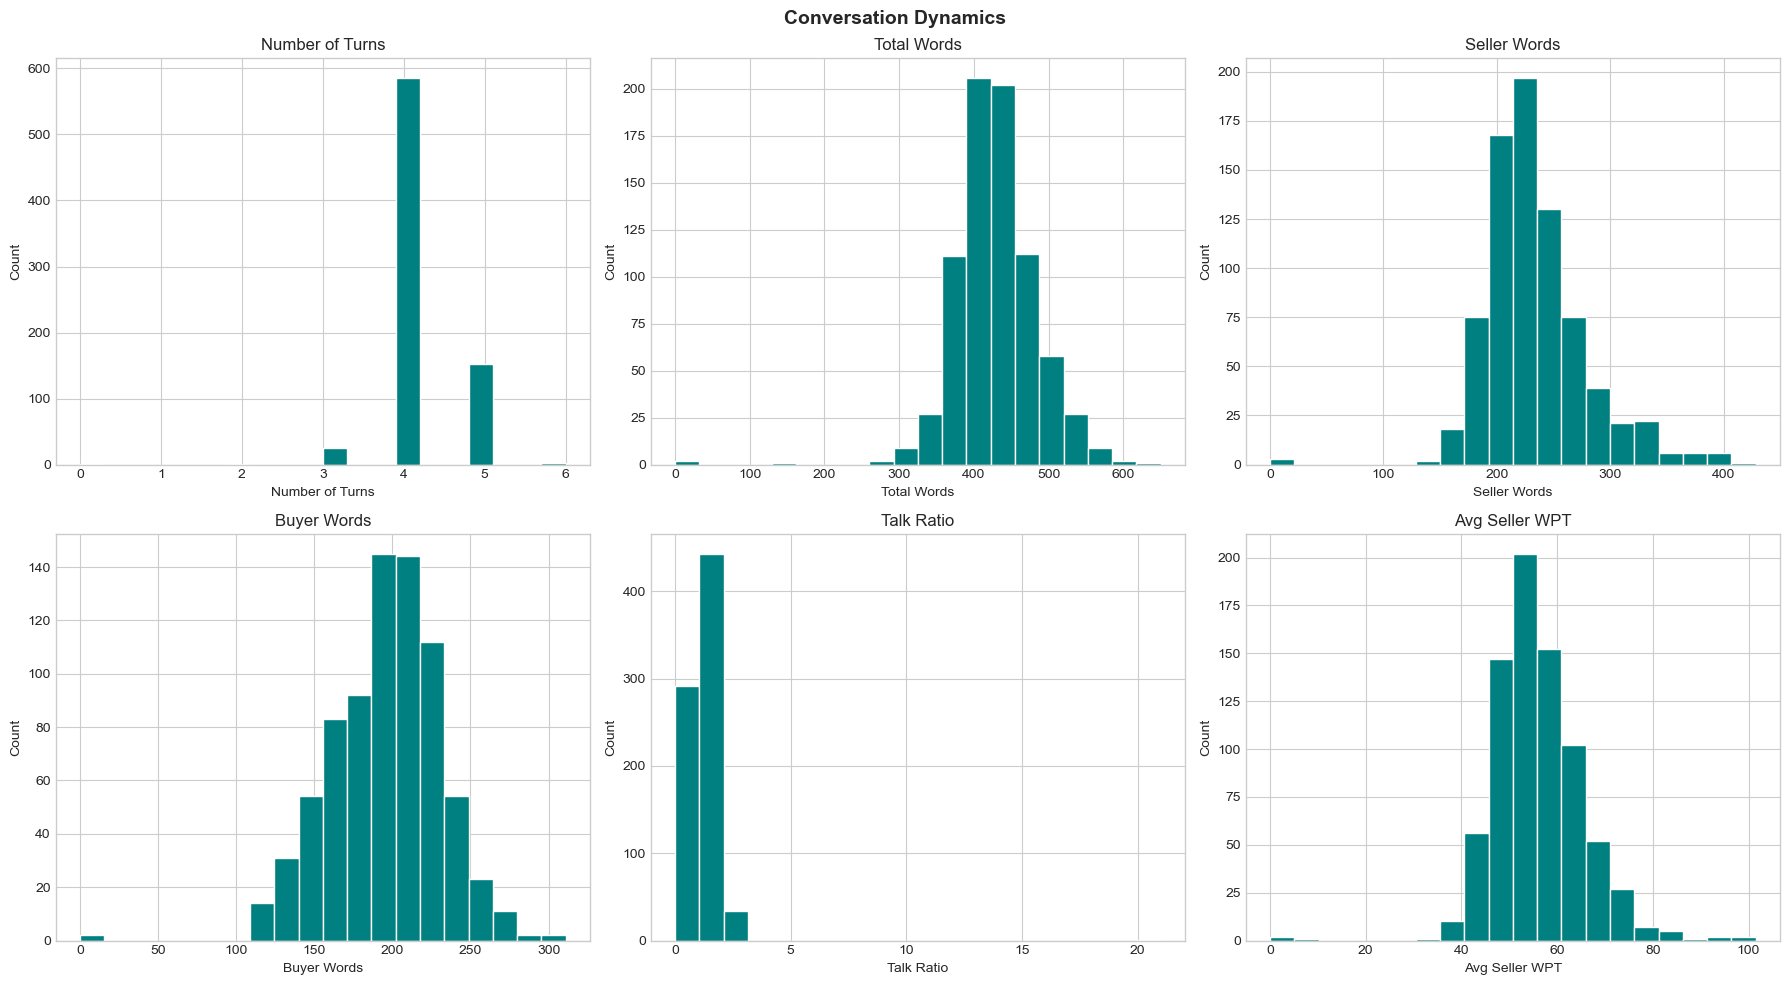

In [7]:
if DATA_LOADED:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    cols = [
        ('num_turns',                 'Number of Turns', axes[0,0]),
        ('total_conversation_length', 'Total Words',     axes[0,1]),
        ('seller_total_words',        'Seller Words',    axes[0,2]),
        ('buyer_total_words',         'Buyer Words',     axes[1,0]),
        ('word_ratio_seller_buyer',   'Talk Ratio',      axes[1,1]),
        ('seller_avg_words_per_turn', 'Avg Seller WPT',  axes[1,2]),
    ]

    for col, title, ax in cols:
        if col in metrics_df.columns:
            metrics_df[col].hist(bins=20, ax=ax, color='teal', edgecolor='white')
            ax.set_title(title)
            ax.set_xlabel(title)
            ax.set_ylabel('Count')

    plt.suptitle('Conversation Dynamics', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [8]:
# Conversation metrics by outcome
if DATA_LOADED:
    numeric_cols = [
        'num_turns', 'seller_total_words', 'buyer_total_words',
        'word_ratio_seller_buyer', 'total_conversation_length', 'score'
    ]
    existing = [c for c in numeric_cols if c in metrics_df.columns]

    grouped = metrics_df.groupby('outcome_label')[existing].mean().round(2)
    print('\n📊 Mean Metrics by Outcome:')
    display(grouped)


📊 Mean Metrics by Outcome:


,num_turns,seller_total_words,buyer_total_words,word_ratio_seller_buyer,total_conversation_length,score
outcome_label,,,,,,
Error,4.00,21.00,0.00,21.00,21.00,0.00
Failure,4.08,221.40,206.16,1.09,427.56,3.50
Pending,3.94,219.66,185.34,1.18,405.00,4.94
Success,4.62,293.95,152.96,1.94,446.91,7.88


## 5. 🧱 Objection Analysis

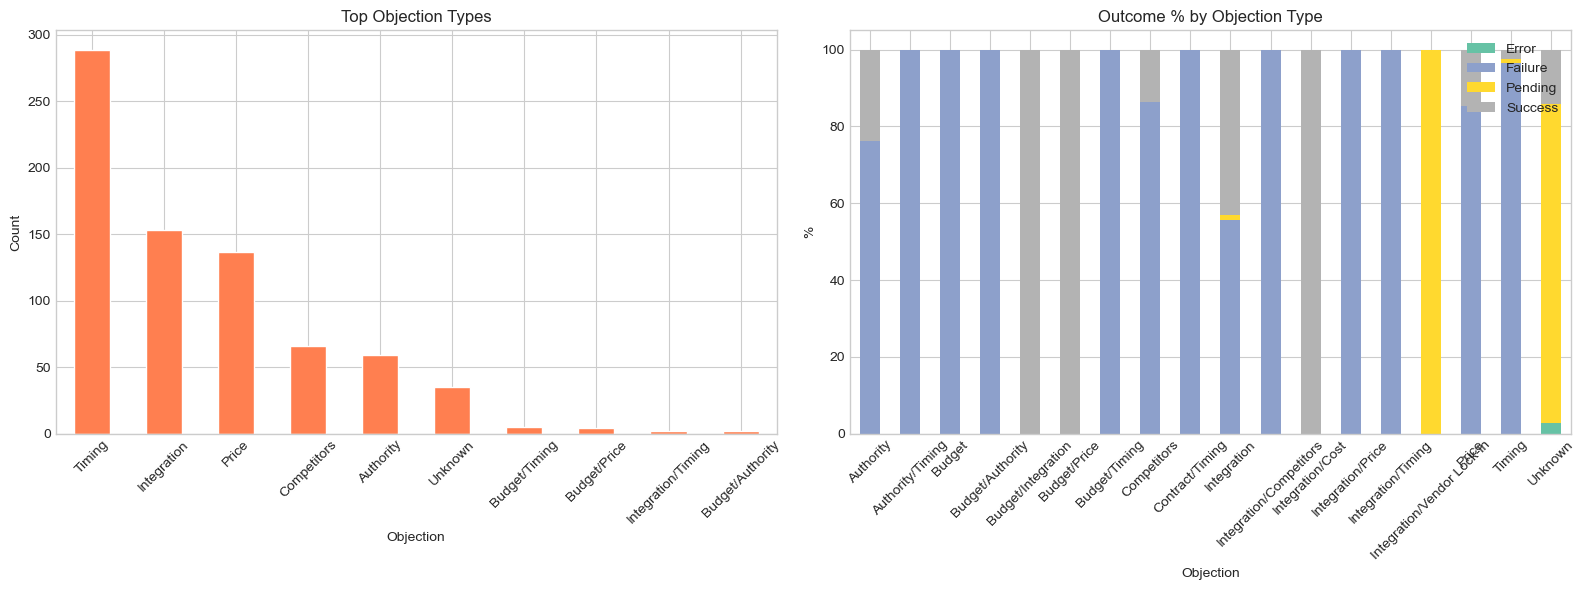

In [9]:
if DATA_LOADED:
    obj_col = 'objection_type' if 'objection_type' in metrics_df.columns else 'key_objection'
    if obj_col in metrics_df.columns:
        obj_counts = metrics_df[obj_col].value_counts().head(10)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        obj_counts.plot(kind='bar', ax=axes[0], color='coral', edgecolor='white')
        axes[0].set_title('Top Objection Types')
        axes[0].set_xlabel('Objection')
        axes[0].set_ylabel('Count')
        axes[0].tick_params(axis='x', rotation=45)

        if 'outcome_label' in metrics_df.columns:
            obj_outcome = pd.crosstab(
                metrics_df[obj_col],
                metrics_df['outcome_label'],
                normalize='index'
            ) * 100
            obj_outcome.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
            axes[1].set_title('Outcome % by Objection Type')
            axes[1].set_xlabel('Objection')
            axes[1].set_ylabel('%')
            axes[1].tick_params(axis='x', rotation=45)
            axes[1].legend(loc='upper right')

        plt.tight_layout()
        plt.show()
    else:
        print('No objection column found.')

## 6. 🔗 Correlation & Feature Analysis

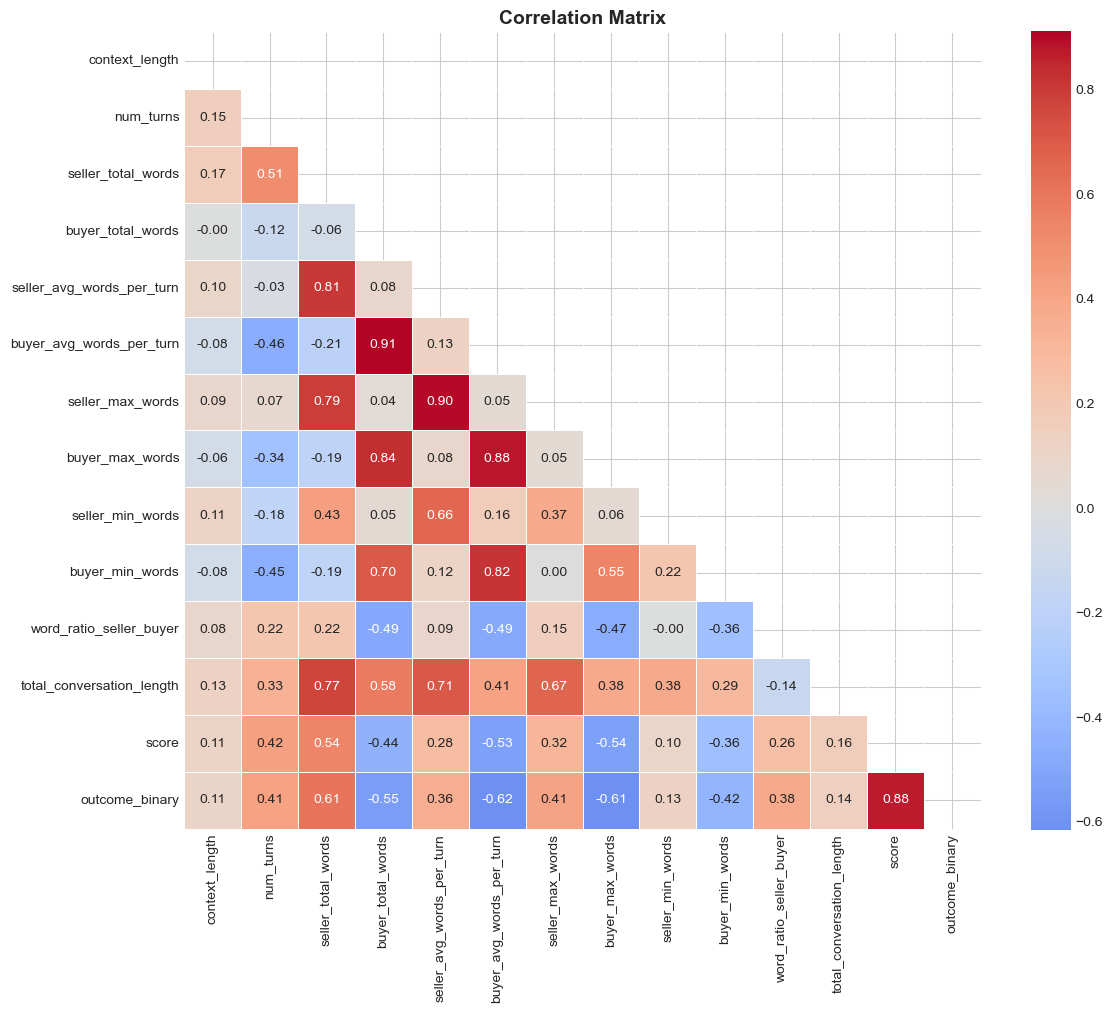


Top correlations with score:
outcome_binary               0.875468
seller_total_words           0.542261
buyer_max_words             -0.536215
buyer_avg_words_per_turn    -0.533669
buyer_total_words           -0.439348
num_turns                    0.422472
buyer_min_words             -0.357007
seller_max_words             0.318619
seller_avg_words_per_turn    0.279150
word_ratio_seller_buyer      0.258687
Name: score, dtype: float64


In [10]:
if DATA_LOADED:
    numeric_cols = metrics_df.select_dtypes(include=[np.number]).columns.tolist()
    corr = metrics_df[numeric_cols].corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, mask=mask, annot=True, fmt='.2f',
        cmap='coolwarm', center=0, ax=ax,
        linewidths=0.5, square=True
    )
    ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Top correlations with score
    print('\nTop correlations with score:')
    score_corr = corr['score'].drop('score').sort_values(key=abs, ascending=False).head(10)
    print(score_corr)

## 7. 📊 Statistical Hypothesis Testing

In [11]:
if DATA_LOADED and 'outcome_label' in metrics_df.columns:
    success = metrics_df[metrics_df['outcome_label'] == 'Success']
    failure = metrics_df[metrics_df['outcome_label'] == 'Failure']

    test_cols = ['score', 'num_turns', 'word_ratio_seller_buyer', 'total_conversation_length']
    test_cols = [c for c in test_cols if c in metrics_df.columns]

    print('🔬 Hypothesis Tests: Success vs Failure')
    print('='*60)
    for col in test_cols:
        stat, p = mannwhitneyu(success[col].dropna(), failure[col].dropna(), alternative='two-sided')
        sig = '✅ Significant' if p < 0.05 else '❌ Not significant'
        print(f'{col:35s}  p={p:.4f}  {sig}')

🔬 Hypothesis Tests: Success vs Failure
score                                p=0.0000  ✅ Significant
num_turns                            p=0.0000  ✅ Significant
word_ratio_seller_buyer              p=0.0000  ✅ Significant
total_conversation_length            p=0.0010  ✅ Significant


## 8. 🔎 Conversation Turn-Level Analysis

In [12]:
if DATA_LOADED and not turns_df.empty:
    print('Turns DataFrame columns:', turns_df.columns.tolist())
    print(turns_df.head(3))

    # Sentiment distribution if available
    sent_col = None
    for c in ['sentiment', 'buyer_sentiment', 'seller_sentiment']:
        if c in turns_df.columns:
            sent_col = c
            break

    if sent_col:
        fig, ax = plt.subplots(figsize=(8, 5))
        turns_df[sent_col].value_counts().plot(kind='bar', ax=ax, color='mediumslateblue')
        ax.set_title(f'Sentiment Distribution ({sent_col})')
        ax.set_xlabel('Sentiment')
        ax.set_ylabel('Count')
        plt.tight_layout()
        plt.show()

Turns DataFrame columns: ['simulation_id', 'turn_number', 'speaker', 'message', 'word_count', 'char_count', 'timestamp']
                          simulation_id  turn_number speaker  \
0  43290c94-50b8-418e-b69a-fe7a0f601def            1  Seller   
1  43290c94-50b8-418e-b69a-fe7a0f601def            1   Buyer   
2  43290c94-50b8-418e-b69a-fe7a0f601def            2  Seller   

                                             message  word_count  char_count  \
0  Alex from DeepData AI. Hope I'm catching you a...          43         251   
1  Alex, always great to hear from another AI ven...          57         327   
2  I completely understand that sentiment, Dr. Re...          66         422   

                    timestamp  
0  2026-02-08T13:04:57.026424  
1  2026-02-08T13:04:57.026424  
2  2026-02-08T13:04:57.026424  


## 9. 🔬 Cluster Analysis

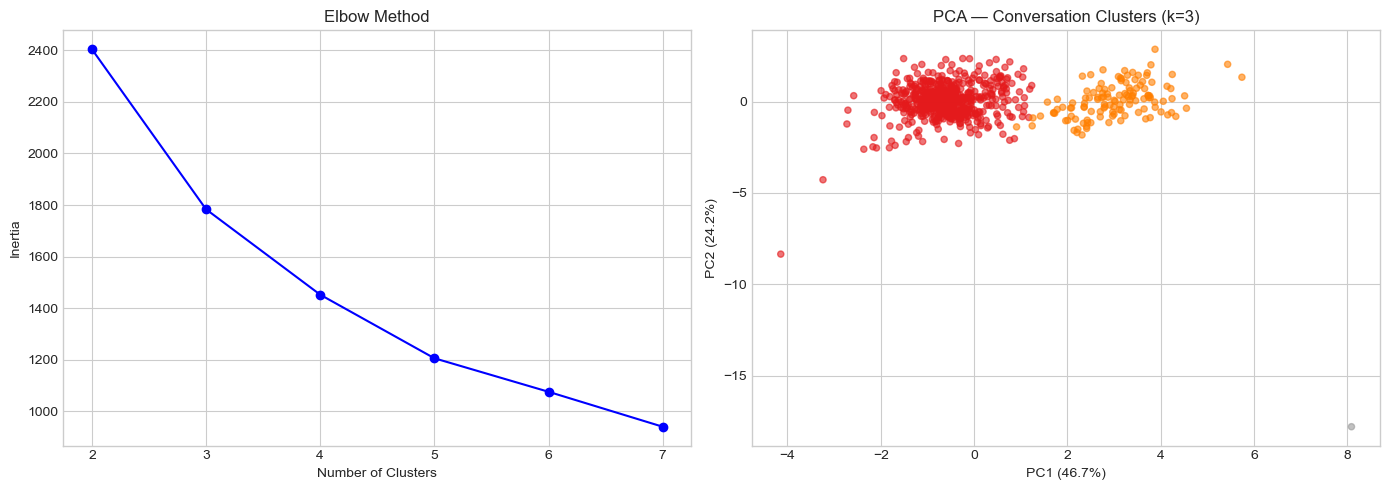

In [13]:
if DATA_LOADED:
    cluster_features = [
        'score', 'num_turns', 'seller_total_words',
        'buyer_total_words', 'word_ratio_seller_buyer'
    ]
    cluster_features = [c for c in cluster_features if c in metrics_df.columns]

    if len(cluster_features) >= 2:
        X_clust = metrics_df[cluster_features].dropna()
        scaler  = StandardScaler()
        X_scaled = scaler.fit_transform(X_clust)

        # Elbow method
        inertias = []
        K = range(2, 8)
        for k in K:
            km = KMeans(n_clusters=k, random_state=42, n_init=10)
            km.fit(X_scaled)
            inertias.append(km.inertia_)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].plot(K, inertias, 'bo-')
        axes[0].set_title('Elbow Method')
        axes[0].set_xlabel('Number of Clusters')
        axes[0].set_ylabel('Inertia')

        # PCA visualisation with k=3
        km = KMeans(n_clusters=3, random_state=42, n_init=10)
        clusters = km.fit_predict(X_scaled)

        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)

        axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='Set1', alpha=0.6, s=20)
        axes[1].set_title('PCA — Conversation Clusters (k=3)')
        axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
        axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

        plt.tight_layout()
        plt.show()
    else:
        print('Not enough numeric features for clustering.')

## 10. 📉 Time-Series Trends

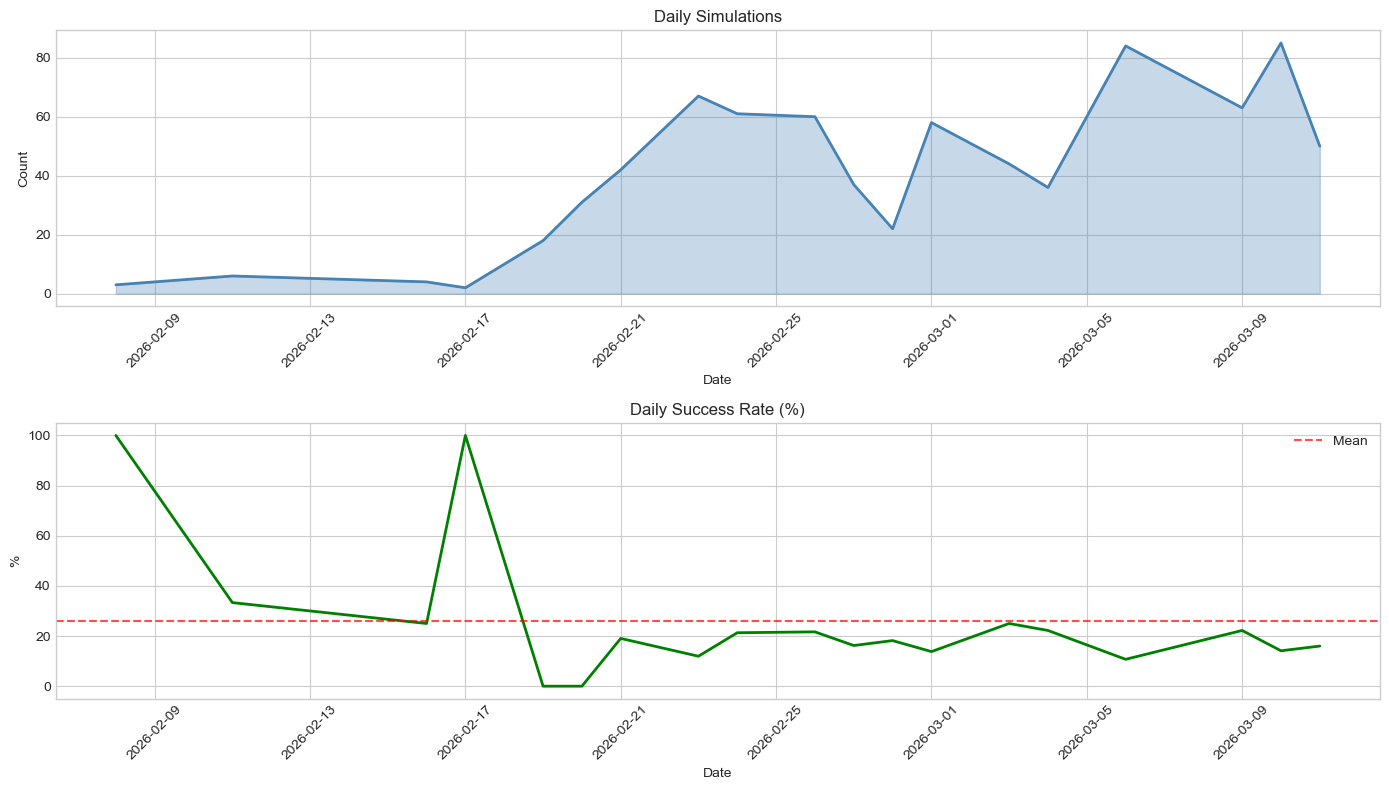

In [14]:
if DATA_LOADED and 'timestamp' in master_df.columns:
    master_df['timestamp'] = pd.to_datetime(master_df['timestamp'], errors='coerce')
    master_df['date'] = master_df['timestamp'].dt.date

    daily = master_df.groupby('date').agg(
        simulations=('simulation_id', 'count'),
        success_rate=('outcome', lambda x: (x == 'Success').mean() * 100)
    ).reset_index()

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    axes[0].plot(daily['date'], daily['simulations'], color='steelblue', linewidth=2)
    axes[0].fill_between(daily['date'], daily['simulations'], alpha=0.3, color='steelblue')
    axes[0].set_title('Daily Simulations')
    axes[0].set_ylabel('Count')

    axes[1].plot(daily['date'], daily['success_rate'], color='green', linewidth=2)
    axes[1].axhline(y=daily['success_rate'].mean(), color='red', linestyle='--', alpha=0.7, label='Mean')
    axes[1].set_title('Daily Success Rate (%)')
    axes[1].set_ylabel('%')
    axes[1].legend()

    for ax in axes:
        ax.set_xlabel('Date')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()
else:
    print('No timestamp column found in master_df — skipping time-series plot.')

## 11. 🏁 Summary & Key Findings

In [15]:
if DATA_LOADED:
    print('='*60)
    print('🏁 SUMMARY OF KEY FINDINGS')
    print('='*60)
    print(f'  Total simulations analysed : {len(metrics_df):,}')
    print(f'  Overall success rate       : {metrics_df["outcome_binary"].mean()*100:.1f}%')
    print(f'  Avg score                  : {metrics_df["score"].mean():.2f}/10')
    print(f'  Avg conversation length    : {metrics_df["total_conversation_length"].mean():.0f} words')
    print(f'  Avg seller talk ratio      : {metrics_df["word_ratio_seller_buyer"].mean():.2f}x')
    print('='*60)

🏁 SUMMARY OF KEY FINDINGS
  Total simulations analysed : 769
  Overall success rate       : 16.8%
  Avg score                  : 4.30/10
  Avg conversation length    : 429 words
  Avg seller talk ratio      : 1.26x
